## Data Load

In [101]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [102]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np  


In [103]:
df=pd.read_csv('marketing_campaign_data_messy.csv')
df

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,11/24/2023 0:00,12/13/2023,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,5/6/2023 0:00,5/12/2023,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,12/13/2023 0:00,12/20/2023,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,10/30/2023,11/3/2023,TikTok,55886,2019,2180.38,135.0,TRUE,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,4/22/2023 0:00,4/23/2023,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,10/31/2023 0:00,11/13/2023,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,9/1/2023 0:00,9/26/2023,Google Ads,20097,897,1641,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2/9/2023 0:00,2/21/2023,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,3/30/2023 0:00,4/27/2023,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA


In [104]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,11/24/2023 0:00,12/13/2023,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,5/6/2023 0:00,5/12/2023,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,12/13/2023 0:00,12/20/2023,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,10/30/2023,11/3/2023,TikTok,55886,2019,2180.38,135.0,TRUE,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,4/22/2023 0:00,4/23/2023,Facebook,7265,169,252.44,30.0,Yes,NaN,FA


In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0    Campaign_ID   2020 non-null   object 
 1   Campaign_Name  2020 non-null   object 
 2   Start_Date     2020 non-null   object 
 3   End_Date       2020 non-null   object 
 4   Channel        1919 non-null   object 
 5   Impressions    2020 non-null   int64  
 6   Clicks         2020 non-null   int64  
 7   Spend          2020 non-null   object 
 8   Conversions    1820 non-null   float64
 9   Active         2020 non-null   object 
 10  Clicks         40 non-null     float64
 11  Campaign_Tag   2020 non-null   object 
dtypes: float64(2), int64(2), object(8)
memory usage: 189.5+ KB


In [106]:
df.describe()

,Impressions,Clicks,Conversions,Clicks
count,2020.000000,2020.000000,1820.000000,40.000000
mean,49839.896040,1500.744059,186.085714,54856.200000
std,28579.637473,1084.765654,160.129172,30552.773369
min,1055.000000,11.000000,0.000000,2508.000000
25%,25033.500000,650.750000,68.000000,30164.750000
50%,50097.500000,1245.000000,142.000000,57707.500000
75%,74784.250000,2185.250000,257.000000,81497.500000
max,99875.000000,4812.000000,943.000000,99483.000000


In [107]:
df.columns

Index([' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel',
       'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active', 'Clicks',
       'Campaign_Tag'],
      dtype='object')

## Data Cleaning & Feature Engineering

In [108]:
df.isnull().sum()

 Campaign_ID        0
Campaign_Name       0
Start_Date          0
End_Date            0
Channel           101
Impressions         0
Clicks              0
Spend               0
Conversions       200
Active              0
Clicks           1980
Campaign_Tag        0
dtype: int64

In [109]:
df['Channel']=df['Channel'].fillna(df['Channel'].mode()[0])

In [110]:
df['Conversions']=df['Conversions'].fillna(df['Conversions'].mean())

In [111]:
df.drop(columns=['Clicks'],axis=1,inplace=True)

In [112]:
df.duplicated().sum()

np.int64(19)

In [113]:
df.drop_duplicates(inplace=True)

In [114]:
df['Active'].value_counts()

Active
1        315
Yes      302
TRUE     297
No       289
FALSE    279
Y        269
0        250
Name: count, dtype: int64

In [115]:
df['Active'] = df['Active'].replace({
    'Yes': 1,
    'TRUE': 1,
    'Y':1,
    '1':1,
    'No': 0,
    'FALSE': 0,
    '0':0
})

C:\Users\USER\AppData\Local\Temp\ipykernel_12196\1737301324.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Active'] = df['Active'].replace({


In [116]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,11/24/2023 0:00,12/13/2023,TikTok,16795,197,$102.82,20.0,1,TI
1,CMP-00002,Q1_Launch_CMP-00002,5/6/2023 0:00,5/12/2023,Facebook,1860,30,24.33,1.0,0,FA
2,CMP-00003,Q3_Winter_CMP-00003,12/13/2023 0:00,12/20/2023,Email,77820,843,1323.39,51.0,0,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,10/30/2023,11/3/2023,TikTok,55886,2019,2180.38,135.0,1,TI
4,CMP-00005,Q2_Winter_CMP-00005,4/22/2023 0:00,4/23/2023,Facebook,7265,169,252.44,30.0,1,FA


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2001 entries, 0 to 2008
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0    Campaign_ID   2001 non-null   object 
 1   Campaign_Name  2001 non-null   object 
 2   Start_Date     2001 non-null   object 
 3   End_Date       2001 non-null   object 
 4   Channel        2001 non-null   object 
 5   Impressions    2001 non-null   int64  
 6   Clicks         2001 non-null   int64  
 7   Spend          2001 non-null   object 
 8   Conversions    2001 non-null   float64
 9   Active         2001 non-null   int64  
 10  Campaign_Tag   2001 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 187.6+ KB


In [118]:
df['Spend'] = df['Spend'].str.replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\USER\AppData\Local\Temp\ipykernel_12196\2479714825.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['Spend'] = df['Spend'].str.replace('[\$,]', '', regex=True).astype(float)


In [119]:
df.head(100)

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,11/24/2023 0:00,12/13/2023,TikTok,16795,197,102.82,20.0,1,TI
1,CMP-00002,Q1_Launch_CMP-00002,5/6/2023 0:00,5/12/2023,Facebook,1860,30,24.33,1.0,0,FA
2,CMP-00003,Q3_Winter_CMP-00003,12/13/2023 0:00,12/20/2023,Email,77820,843,1323.39,51.0,0,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,10/30/2023,11/3/2023,TikTok,55886,2019,2180.38,135.0,1,TI
4,CMP-00005,Q2_Winter_CMP-00005,4/22/2023 0:00,4/23/2023,Facebook,7265,169,252.44,30.0,1,FA
...,...,...,...,...,...,...,...,...,...,...,...
95,CMP-00096,Q1_Winter_CMP-00096,6/10/2023 0:00,6/28/2023,Google Ads,52214,1352,945.00,225.0,0,GO
96,CMP-00097,Q3_Summer_CMP-00097,12/10/2023 0:00,12/21/2023,Email,62228,1816,2301.70,233.0,0,EM
97,CMP-00098,Q4_Summer_CMP-00098,7/2/2023,2/26/2023,TikTok,49984,1871,950.50,273.0,0,XX
98,CMP-00099,Q4_BlackFriday_CMP-00099,11/15/2023 0:00,12/11/2023,Instagram,41774,446,850.80,74.0,0,IN


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2001 entries, 0 to 2008
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0    Campaign_ID   2001 non-null   object 
 1   Campaign_Name  2001 non-null   object 
 2   Start_Date     2001 non-null   object 
 3   End_Date       2001 non-null   object 
 4   Channel        2001 non-null   object 
 5   Impressions    2001 non-null   int64  
 6   Clicks         2001 non-null   int64  
 7   Spend          2001 non-null   float64
 8   Conversions    2001 non-null   float64
 9   Active         2001 non-null   int64  
 10  Campaign_Tag   2001 non-null   object 
dtypes: float64(2), int64(3), object(6)
memory usage: 187.6+ KB


In [121]:
df['Active'].value_counts()

Active
1    1183
0     818
Name: count, dtype: int64

In [122]:
df['Channel'].value_counts()

Channel
TikTok        496
Facebook      388
Email         355
Google Ads    340
Instagram     339
E-mail         21
Insta_gram     19
Tik_Tok        16
Gogle          14
Facebok        13
Name: count, dtype: int64

In [123]:
df['Channel'] = df['Channel'].replace({
    'TikTok': 'TikTok',
    'Tik_Tok': 'TikTok',
    'Facebook':'Facebook',
    'Facebok':'Facebook',
    'Email': 'Email',
    'E-mail': 'Email',
    'Google Ads':'Google Ads',
    'Gogle': 'Google Ads',
    'Instagram':'Instagram',
    'Insta_gram':'Instagram'

})

In [124]:
df['Campaign_Tag'].value_counts()

Campaign_Tag
TI         397
FA         387
IN         342
EM         331
GO         331
INVALID    101
XX          92
E-          20
Name: count, dtype: int64

In [125]:
df['Campaign_Tag'] = df['Campaign_Tag'].replace({
    'TI': 'TI',
    'FA': 'FA',
    'IN':'IN',
    'EM':'EM',
    'GO': 'GO',
    'E-': 'EM',
    'INVALID':'EM',
    'XX': 'TI'

})

In [126]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,11/24/2023 0:00,12/13/2023,TikTok,16795,197,102.82,20.0,1,TI
1,CMP-00002,Q1_Launch_CMP-00002,5/6/2023 0:00,5/12/2023,Facebook,1860,30,24.33,1.0,0,FA
2,CMP-00003,Q3_Winter_CMP-00003,12/13/2023 0:00,12/20/2023,Email,77820,843,1323.39,51.0,0,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,10/30/2023,11/3/2023,TikTok,55886,2019,2180.38,135.0,1,TI
4,CMP-00005,Q2_Winter_CMP-00005,4/22/2023 0:00,4/23/2023,Facebook,7265,169,252.44,30.0,1,FA


In [127]:
df.columns

Index([' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel',
       'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active',
       'Campaign_Tag'],
      dtype='object')

In [128]:
df['Campaign_Tag'].value_counts()

Campaign_Tag
TI    489
EM    452
FA    387
IN    342
GO    331
Name: count, dtype: int64

In [129]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,11/24/2023 0:00,12/13/2023,TikTok,16795,197,102.82,20.0,1,TI
1,CMP-00002,Q1_Launch_CMP-00002,5/6/2023 0:00,5/12/2023,Facebook,1860,30,24.33,1.0,0,FA
2,CMP-00003,Q3_Winter_CMP-00003,12/13/2023 0:00,12/20/2023,Email,77820,843,1323.39,51.0,0,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,10/30/2023,11/3/2023,TikTok,55886,2019,2180.38,135.0,1,TI
4,CMP-00005,Q2_Winter_CMP-00005,4/22/2023 0:00,4/23/2023,Facebook,7265,169,252.44,30.0,1,FA


In [130]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'], format='mixed', errors='coerce')
df['End_Date'] = pd.to_datetime(df['End_Date'], format='mixed', errors='coerce')

In [131]:
df.dtypes

 Campaign_ID             object
Campaign_Name            object
Start_Date       datetime64[ns]
End_Date         datetime64[ns]
Channel                  object
Impressions               int64
Clicks                    int64
Spend                   float64
Conversions             float64
Active                    int64
Campaign_Tag             object
dtype: object

In [132]:
print(df['Start_Date'].head())
print(df['End_Date'].head())

0   2023-11-24
1   2023-05-06
2   2023-12-13
3   2023-10-30
4   2023-04-22
Name: Start_Date, dtype: datetime64[ns]
0   2023-12-13
1   2023-05-12
2   2023-12-20
3   2023-11-03
4   2023-04-23
Name: End_Date, dtype: datetime64[ns]


In [133]:
mask = df['End_Date'] < df['Start_Date']

df.loc[mask, ['Start_Date', 'End_Date']] = df.loc[mask, ['End_Date', 'Start_Date']].values

In [134]:
df['Duration'] = (df['End_Date'] - df['Start_Date']).dt.days

## Data Visualisation

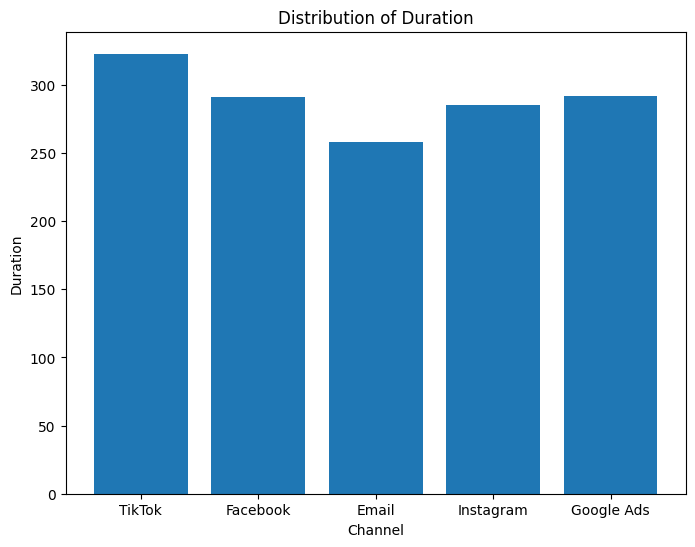

In [135]:
plt.figure(figsize=(8,6))
plt.bar(df['Channel'],df['Duration'])
plt.xlabel('Channel')
plt.ylabel('Duration')
plt.title('Distribution of Duration')
plt.show()

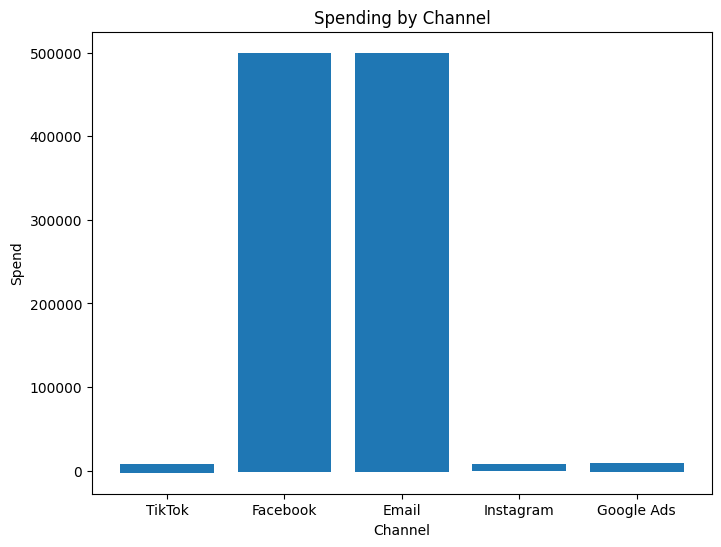

In [136]:
plt.figure(figsize=(8,6))
plt.bar(df['Channel'],df['Spend'])
plt.xlabel('Channel')
plt.ylabel('Spend')
plt.title('Spending by Channel')
plt.show()

In [137]:
df.groupby('Channel')['Spend'].agg(['sum', 'mean', 'count'])

,sum,mean,count
Channel,,,
Email,2198187.19,5846.242527,376
Facebook,1769251.02,4412.097307,401
Google Ads,678345.78,1916.231017,354
Instagram,634834.94,1773.281955,358
TikTok,937550.77,1831.153848,512


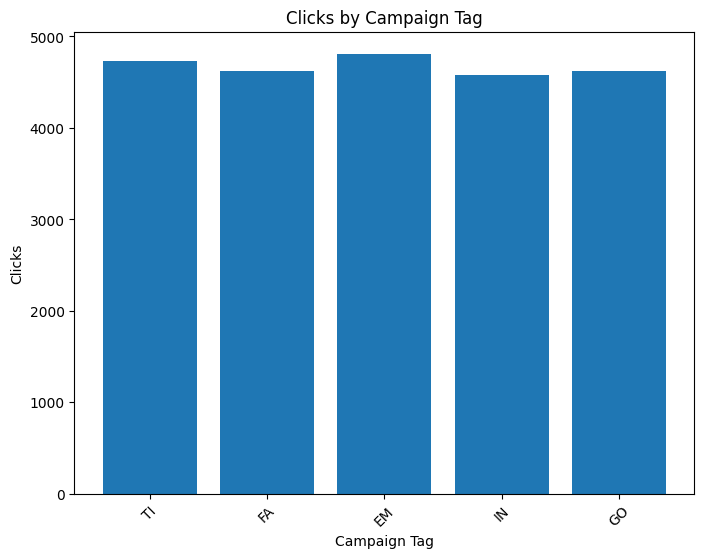

In [138]:
plt.figure(figsize=(8,6))
plt.bar(df['Campaign_Tag'],df['Clicks '])
plt.xlabel('Campaign Tag')
plt.xticks(rotation=45)
plt.ylabel('Clicks')
plt.title('Clicks by Campaign Tag')
plt.show()

- Duration does NOT strongly impact clicks in your data
- Some short campaigns perform very well

In [139]:
df_filtered = df[df['Duration'] > 5]

In [140]:
df['Clicks_per_Day'] = df['Clicks '] / df['Duration']

In [141]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag,Duration,Clicks_per_Day
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,TikTok,16795,197,102.82,20.0,1,TI,19,10.368421
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,Facebook,1860,30,24.33,1.0,0,FA,6,5.000000
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,Email,77820,843,1323.39,51.0,0,EM,7,120.428571
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,1,TI,4,504.750000
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,Facebook,7265,169,252.44,30.0,1,FA,1,169.000000


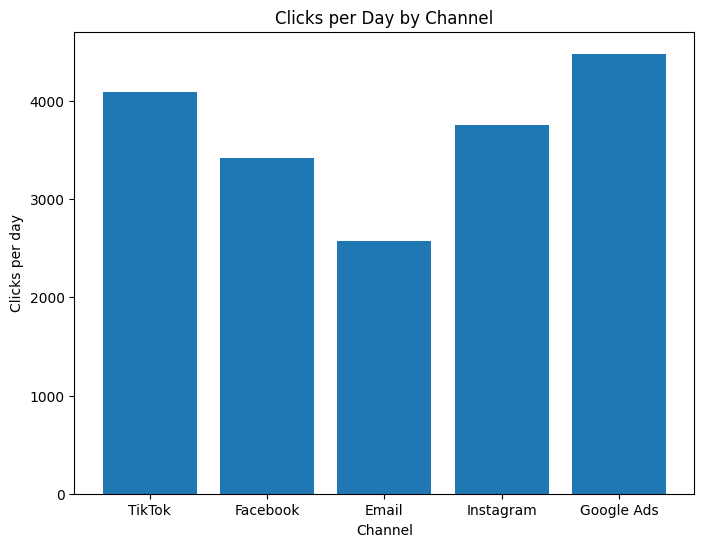

In [142]:
plt.figure(figsize=(8,6))
plt.bar(df['Channel'],df['Clicks_per_Day'])
plt.xlabel('Channel')
plt.ylabel('Clicks per day')
plt.title('Clicks per Day by Channel')
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_12196\3796436358.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(pd.cut(df['Duration'], bins=[0,10,30,60,120,300]))['Clicks '].mean()


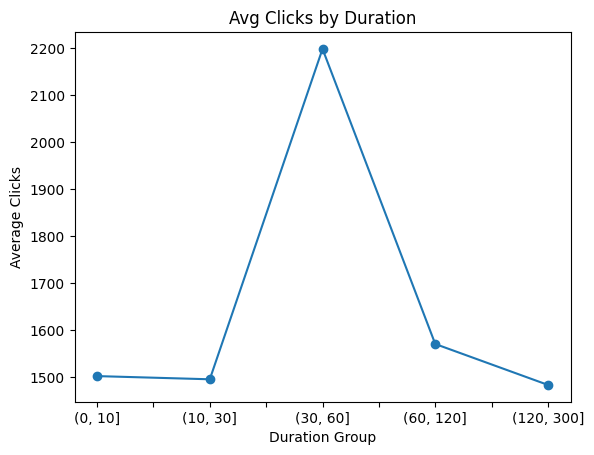

In [143]:
grouped = df.groupby(pd.cut(df['Duration'], bins=[0,10,30,60,120,300]))['Clicks '].mean()

grouped.plot(marker='o')
plt.xlabel('Duration Group')
plt.ylabel('Average Clicks')
plt.title('Avg Clicks by Duration')
plt.show()

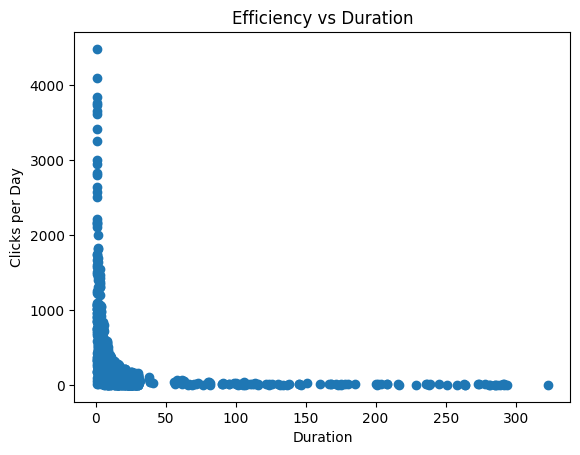

In [144]:
plt.figure()
plt.scatter(df['Duration'], df['Clicks_per_Day'])
plt.xlabel('Duration')
plt.ylabel('Clicks per Day')
plt.title('Efficiency vs Duration')
plt.show()

In [145]:
df['Channel'].value_counts()

Channel
TikTok        512
Facebook      401
Email         376
Instagram     358
Google Ads    354
Name: count, dtype: int64

In [146]:
df.to_csv(r"C:\Users\USER\Desktop\cleaned_marketing_campaign_data.csv", index=False)

## Encoding 

In [147]:
df = pd.get_dummies(df, columns=['Channel'], drop_first=False)

In [148]:
df['CTR'] = df['Clicks '] / df['Impressions']

In [149]:
df['CPC'] = df['Spend'] / df['Clicks ']

In [150]:
df.head()

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Impressions,Clicks,Spend,Conversions,Active,Campaign_Tag,Duration,Clicks_per_Day,Channel_Email,Channel_Facebook,Channel_Google Ads,Channel_Instagram,Channel_TikTok,CTR,CPC
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24,2023-12-13,16795,197,102.82,20.0,1,TI,19,10.368421,False,False,False,False,True,0.011730,0.521929
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06,2023-05-12,1860,30,24.33,1.0,0,FA,6,5.000000,False,True,False,False,False,0.016129,0.811000
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13,2023-12-20,77820,843,1323.39,51.0,0,EM,7,120.428571,True,False,False,False,False,0.010833,1.569858
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,55886,2019,2180.38,135.0,1,TI,4,504.750000,False,False,False,False,True,0.036127,1.079931
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22,2023-04-23,7265,169,252.44,30.0,1,FA,1,169.000000,False,True,False,False,False,0.023262,1.493728


In [151]:
df.columns

Index([' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date',
       'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active',
       'Campaign_Tag', 'Duration', 'Clicks_per_Day', 'Channel_Email',
       'Channel_Facebook', 'Channel_Google Ads', 'Channel_Instagram',
       'Channel_TikTok', 'CTR', 'CPC'],
      dtype='object')

In [152]:
# Define features and target variable
features = [
    'Spend',
    'Duration',
    'Clicks ',
    'Impressions',
    'CTR',
    'CPC',
    'Channel_Email',
    'Channel_Facebook',
    'Channel_Google Ads',
    'Channel_Instagram',
    'Channel_TikTok'
]

X = df[features]
y = df['Conversions']

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "Elastic Net": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "Support Vector Regressor": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "Neural Network (MLP)": MLPRegressor(max_iter=1000, random_state=42)
}
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import pandas as pd
import numpy as np

results = []

for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results).sort_values(by="R² Score", ascending=False)

results_df

,Model,MAE,RMSE,R² Score
2,Lasso Regression,63.260598,86.187210,0.665001
3,Elastic Net,63.259842,86.188111,0.664994
1,Ridge Regression,63.212412,86.210271,0.664822
0,Linear Regression,63.191513,86.221870,0.664732
8,AdaBoost,68.563710,88.963481,0.643071
7,Gradient Boosting,66.743466,91.801179,0.619938
5,Random Forest,67.316186,92.737380,0.612147
6,Extra Trees,68.178508,93.590503,0.604978
11,Neural Network (MLP),68.761587,94.489082,0.597356
10,K-Nearest Neighbors,68.831692,95.453302,0.589097


In [154]:
best_model = results_df.iloc[0]
print("Best Model:")
print(best_model)

Best Model:
Model       Lasso Regression
MAE                63.260598
RMSE                86.18721
R² Score            0.665001
Name: 2, dtype: object
